# World Cup Score Predictor - Model Optimization
**Goal**: Reach 40% exact score accuracy using ensemble methods and tuning

- Baseline (notebook 03): 20%
- Reference (notebook 05): 29.69%
- Target: 35-40%

In [1]:
import sys
sys.path.insert(0, '..')  # Add parent directory to path

import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple, List, Optional

warnings.filterwarnings('ignore')
%matplotlib inline

# Import project modules
from src.models.base import load_model_dataset, coerce_goal_array, ensure_non_negative
from src.models.baseline import AverageGoalsBaseline, EloHeuristicBaseline
from src.models.poisson_model import PoissonGoalModel
from src.models.tree_model import TreeGoalModel
from src.models.ensemble import EnsembleGoalModel
from src.prediction.score_conversion import convert_expected_goals_to_scores
from src.models.world_cup_utils import (
    validate_dataset_quality,
    filter_world_cup_matches,
    filter_major_tournaments,
    get_world_cup_years,
    create_expanding_window_splits,
    prepare_feature_sets,
    evaluate_world_cup_only,
    rank_models_by_accuracy,
    standardize_goal_columns
)

print("All imports successful!")

c:\Users\yuval\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\yuval\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


All imports successful!


## Phase 1: Data Loading & Quality Checks

In [2]:
# Load dataset
df = load_model_dataset('../data/processed/model_dataset.csv', standardize=False)
print(f"Loaded {len(df)} matches with {len(df.columns)} columns")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nColumns: {df.columns.tolist()}")

Loaded 21539 matches with 43 columns
Date range: 2004-01-01 to 2026-05-16

Columns: ['date', 'team_a', 'team_b', 'competition', 'location', 'season_id', 'tournament_year', 'tournament_key', 'rating_a_before', 'rating_b_before', 'elo_diff', 'rank_diff', 'log_market_value_a', 'log_market_value_b', 'log_market_value_diff', 'log_market_value_year_centered_a', 'log_market_value_year_centered_b', 'log_market_value_year_centered_diff', 'market_value_rel_mean_a', 'market_value_rel_mean_b', 'market_value_rel_mean_diff', 'market_value_zscore_diff', 'avg_player_value_diff', 'form_diff_last5', 'weighted_goals_for_diff_last5', 'weighted_goals_against_diff_last5', 'opponent_strength_diff_last5', 'rating_change_diff_last5', 'team_a_matches_played_before', 'team_b_matches_played_before', 'team_a_days_since_last_match', 'team_b_days_since_last_match', 'days_since_match_diff', 'team_a_tournament_matches_played', 'team_b_tournament_matches_played', 'tournament_points_diff', 'tournament_goal_diff_diff', '

In [3]:
# Standardize column names
df = standardize_goal_columns(df)
df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'])

# Data quality checks
print("Running data quality checks...\n")
issues = validate_dataset_quality(df)

if issues:
    print("Issues found:")
    for issue_type, details in issues.items():
        if issue_type in ('competition_distribution', 'feature_ranges', 'high_zero_value_features'):
            continue  # skip verbose sections
        print(f"\n  {issue_type}:")
        if isinstance(details, dict):
            for key, value in list(details.items())[:5]:
                print(f"    {key}: {value:.2f}" if isinstance(value, float) else f"    {key}: {value}")
else:
    print("No major data quality issues detected")


Running data quality checks...

Issues found:

  days_since_match_diff_mismatches:
    count: 5391
    percentage: 25.03


In [4]:
# Prepare feature sets
feat_a, feat_b = prepare_feature_sets(df)
print(f"\nFeature Set A (current): {len(feat_a)} features")
print(f"Feature Set B (with state): {len(feat_b)} features")
print(f"State-only features: {set(feat_b) - set(feat_a)}")

Feature Set A (no state): 27 features
Feature Set B (with state): 31 features
State-only features: {'team_b_tournament_matches_played', 'tournament_points_diff', 'team_a_tournament_matches_played', 'tournament_goal_diff_diff'}

Feature Set A (current): 27 features
Feature Set B (with state): 31 features
State-only features: {'team_b_tournament_matches_played', 'tournament_points_diff', 'team_a_tournament_matches_played', 'tournament_goal_diff_diff'}


## Phase 2: Tournament Isolation

In [5]:
# Extract World Cup matches
wc_df = filter_world_cup_matches(df)
wc_df = wc_df[wc_df['competition'] == 'World Cup']
wc_years = get_world_cup_years(wc_df)

print(f"Found {len(wc_df)} World Cup matches")
print(f"\nWorld Cup years: {wc_years}")
for year in wc_years:
    year_count = len(wc_df[wc_df['tournament_year'] == year])
    print(f"  {year}: {year_count} matches")


Found 320 World Cup matches

World Cup years: [2006, 2010, 2014, 2018, 2022]
  2006: 64 matches
  2010: 64 matches
  2014: 64 matches
  2018: 64 matches
  2022: 64 matches


In [6]:
# Extract major tournaments
major_df = filter_major_tournaments(df)
major_df = major_df[major_df['competition'].isin(['European Championship', 'Copa America', 'African Nations Cup', 'Asian Cup'])]  # Exclude World Cup from major tournaments
print(f"\nFound {len(major_df)} major tournament matches")
if 'competition' in major_df.columns:
    print(f"\nBreakdown:")
    print(major_df['competition'].value_counts())


Found 1159 major tournament matches

Breakdown:
competition
African Nations Cup      461
European Championship    246
Asian Cup                230
Copa America             222
Name: count, dtype: int64


In [7]:
# Create expanding-window splits for each WC
print("Creating expanding-window train/test splits...\n")
splits = create_expanding_window_splits(wc_df, wc_years)
print(f"\nSplits created for years: {list(splits.keys())}")

Creating expanding-window train/test splits...

Year 2010: train=64, test=64
Year 2014: train=128, test=64
Year 2018: train=192, test=64
Year 2022: train=256, test=64

Splits created for years: [2010, 2014, 2018, 2022]


## Phase 3: Model Training & Evaluation

Train and compare models on each World Cup year

In [8]:
def train_and_evaluate_models(
    X_train, y_train, X_test, y_test,
    feature_set_name="Features",
    sample_weight=None
):
    """Train multiple models and evaluate."""
    print(f"Training models with {feature_set_name}...\n")
    results = {}
    
    y_train = coerce_goal_array(y_train)
    y_test = coerce_goal_array(y_test)
    
    # Baselines
    avg = AverageGoalsBaseline().fit(X_train, y_train)
    y_pred = avg.predict(X_test)
    y_scores = convert_expected_goals_to_scores(y_pred, method='poisson')
    metrics = evaluate_world_cup_only(y_test, y_scores, y_pred)
    results['Average'] = metrics
    
    elo = EloHeuristicBaseline().fit(X_train, y_train)
    y_pred = elo.predict(X_test)
    y_scores = convert_expected_goals_to_scores(y_pred, method='poisson')
    metrics = evaluate_world_cup_only(y_test, y_scores, y_pred)
    results['ELO'] = metrics
    
    # Poisson
    pois = PoissonGoalModel(alpha=1.0).fit(X_train, y_train, sample_weight=sample_weight)
    y_pred = pois.predict(X_test)
    y_scores = convert_expected_goals_to_scores(y_pred, method='poisson')
    metrics = evaluate_world_cup_only(y_test, y_scores, y_pred)
    results['Poisson'] = metrics
    
    # RandomForest
    tree = TreeGoalModel(n_estimators=300, max_depth=12).fit(X_train, y_train, sample_weight=sample_weight)
    y_pred = tree.predict(X_test)
    y_scores = convert_expected_goals_to_scores(y_pred, method='poisson')
    metrics = evaluate_world_cup_only(y_test, y_scores, y_pred)
    results['RandomForest'] = metrics
    
    # XGBoost (optional)
    try:
        import xgboost as xgb
        xgb_a = xgb.XGBRegressor(n_estimators=200, max_depth=8, learning_rate=0.05, random_state=42, n_jobs=-1)
        xgb_b = xgb.XGBRegressor(n_estimators=200, max_depth=8, learning_rate=0.05, random_state=42, n_jobs=-1)
        
        xgb_a.fit(X_train, y_train[:, 0], sample_weight=sample_weight)
        xgb_b.fit(X_train, y_train[:, 1], sample_weight=sample_weight)
        
        y_pred = np.column_stack([xgb_a.predict(X_test), xgb_b.predict(X_test)])
        y_pred = ensure_non_negative(y_pred)
        y_scores = convert_expected_goals_to_scores(y_pred, method='poisson')
        metrics = evaluate_world_cup_only(y_test, y_scores, y_pred)
        results['XGBoost'] = metrics
    except ImportError:
        print("  (XGBoost not available)")
    
    # LightGBM (optional)
    try:
        import lightgbm as lgb
        params = {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05, 'random_state': 42, 'verbose': -1}
        
        lgb_a = lgb.LGBMRegressor(**params).fit(X_train, y_train[:, 0], sample_weight=sample_weight)
        lgb_b = lgb.LGBMRegressor(**params).fit(X_train, y_train[:, 1], sample_weight=sample_weight)
        
        y_pred = np.column_stack([lgb_a.predict(X_test), lgb_b.predict(X_test)])
        y_pred = ensure_non_negative(y_pred)
        y_scores = convert_expected_goals_to_scores(y_pred, method='poisson')
        metrics = evaluate_world_cup_only(y_test, y_scores, y_pred)
        results['LightGBM'] = metrics
    except ImportError:
        print("  (LightGBM not available)")
    
    return results

print("Function ready. Run next cell for 2022 WC example.")

Function ready. Run next cell for 2022 WC example.


In [9]:
# Example: Train and evaluate on 2022 World Cup
year = 2022

if year in splits:
    train_df, test_df = splits[year]
    goal_cols = ['goals_a', 'goals_b'] if 'goals_a' in train_df.columns else ['target_goals_a', 'target_goals_b']

    # Feature Set A (current)
    X_train = train_df[feat_a].values
    y_train = train_df[goal_cols].values
    X_test = test_df[feat_a].values
    y_test = test_df[goal_cols].values

    print(f"\n{year} World Cup - Feature Set A")
    print(f"Train: {X_train.shape[0]} matches, Test: {X_test.shape[0]} matches\n")

    results_a = train_and_evaluate_models(X_train, y_train, X_test, y_test, "Feature Set A")

    # Display ranking
    ranking = rank_models_by_accuracy(results_a, metric='exact_score_accuracy')
    print("\nModel Rankings (Feature Set A):")
    print(ranking[['Model', 'exact_score_accuracy', 'result_accuracy', 'rounded_score_mae']].to_string(index=False))



2022 World Cup - Feature Set A
Train: 256 matches, Test: 64 matches

Training models with Feature Set A...


Model Rankings (Feature Set A):
       Model  exact_score_accuracy  result_accuracy  rounded_score_mae
     Poisson               29.6875          76.5625           0.750000
RandomForest               21.8750          68.7500           0.757812
     XGBoost               17.1875          71.8750           0.789062
    LightGBM               17.1875          73.4375           0.781250
     Average               15.6250          71.8750           0.859375
         ELO               15.6250          71.8750           0.859375


In [10]:
# Feature Set B comparison (with state features)
if year in splits and len(feat_b) > len(feat_a):
    train_df, test_df = splits[year]
    
    X_train_b = train_df[feat_b].values
    X_test_b = test_df[feat_b].values
    
    print(f"\n{year} World Cup - Feature Set B (with state features)")
    print(f"Train: {X_train_b.shape[0]} matches, Test: {X_test_b.shape[0]} matches\n")
    
    results_b = train_and_evaluate_models(X_train_b, y_train, X_test_b, y_test, "Feature Set B")
    
    # Display ranking
    ranking_b = rank_models_by_accuracy(results_b, metric='exact_score_accuracy')
    print("\nModel Rankings (Feature Set B):")
    print(ranking_b[['Model', 'exact_score_accuracy', 'result_accuracy', 'rounded_score_mae']].to_string(index=False))
    
    # Compare
    print("\nFeature Set Comparison (Poisson model):")
    print(f"  Set A accuracy: {results_a['Poisson']['exact_score_accuracy']:.2f}%")
    print(f"  Set B accuracy: {results_b['Poisson']['exact_score_accuracy']:.2f}%")
    print(f"  Delta: {results_b['Poisson']['exact_score_accuracy'] - results_a['Poisson']['exact_score_accuracy']:.2f}%")
else:
    print(f"No state features found. Feature Set B identical to Set A.")


2022 World Cup - Feature Set B (with state features)
Train: 256 matches, Test: 64 matches

Training models with Feature Set B...


Model Rankings (Feature Set B):
       Model  exact_score_accuracy  result_accuracy  rounded_score_mae
     Poisson               26.5625          73.4375           0.781250
RandomForest               23.4375          68.7500           0.765625
     XGBoost               21.8750          73.4375           0.765625
    LightGBM               21.8750          71.8750           0.765625
     Average               15.6250          71.8750           0.859375
         ELO               15.6250          71.8750           0.859375

Feature Set Comparison (Poisson model):
  Set A accuracy: 29.69%
  Set B accuracy: 26.56%
  Delta: -3.12%


## Experiment: Try All World Cup Years

In [11]:
# Train on all WC years and collect results
all_results = {}

for year in sorted(wc_years):
    if year not in splits:
        continue

    train_df, test_df = splits[year]
    goal_cols = ['goals_a', 'goals_b'] if 'goals_a' in train_df.columns else ['target_goals_a', 'target_goals_b']

    X_train = train_df[feat_a].values
    y_train = train_df[goal_cols].values
    X_test = test_df[feat_a].values
    y_test = test_df[goal_cols].values

    print(f"\n{'='*60}")
    print(f"Training {year} World Cup (train: {len(train_df)}, test: {len(test_df)} matches)")
    print(f"{'='*60}")

    results = train_and_evaluate_models(X_train, y_train, X_test, y_test, "Feature Set A")
    all_results[year] = results

    ranking = rank_models_by_accuracy(results, metric='exact_score_accuracy')
    print(f"\nTop model: {ranking.iloc[0]['Model']} at {ranking.iloc[0]['exact_score_accuracy']:.2f}%")



Training 2010 World Cup (train: 64, test: 64 matches)
Training models with Feature Set A...


Top model: Average at 26.56%

Training 2014 World Cup (train: 128, test: 64 matches)
Training models with Feature Set A...


Top model: Poisson at 21.88%

Training 2018 World Cup (train: 192, test: 64 matches)
Training models with Feature Set A...


Top model: Average at 23.44%

Training 2022 World Cup (train: 256, test: 64 matches)
Training models with Feature Set A...


Top model: Poisson at 29.69%


In [12]:
# Summary: Best accuracy across all years
summary_data = []

for year in sorted(all_results.keys()):
    for model_name, metrics in all_results[year].items():
        summary_data.append({
            'Year': year,
            'Model': model_name,
            'Exact Score %': metrics['exact_score_accuracy'],
            'Result %': metrics['result_accuracy'],
            'Goal MAE': metrics.get('goal_mae', np.nan)
        })

summary_df = pd.DataFrame(summary_data)

print("\nBest Exact Score Accuracy by Year:")
for year in sorted(all_results.keys()):
    year_data = summary_df[summary_df['Year'] == year]
    best = year_data.loc[year_data['Exact Score %'].idxmax()]
    print(f"  {year}: {best['Model']:15} {best['Exact Score %']:6.2f}%")

print("\nOverall Best Model by Average Accuracy:")
avg_by_model = summary_df.groupby('Model')['Exact Score %'].mean().sort_values(ascending=False)
for model, avg_acc in avg_by_model.head(5).items():
    print(f"  {model:15} {avg_acc:6.2f}%")


Best Exact Score Accuracy by Year:
  2010: Average          26.56%
  2014: Poisson          21.88%
  2018: Average          23.44%
  2022: Poisson          29.69%

Overall Best Model by Average Accuracy:
  Average          21.09%
  ELO              21.09%
  LightGBM         18.75%
  RandomForest     18.75%
  Poisson          17.58%


## Next Steps

1. **Feature Engineering**: Try interactions, transformations
2. **Hyperparameter Tuning**: Use Optuna for deeper optimization  
3. **Ensemble Methods**: Combine best models
4. **Sample Weighting**: Experiment with competition weights, temporal decay
5. **Domain-Specific Models**: Separate group stage vs. knockout models


## Phase 2: Model Architecture, Feature Importance & Actual Predictions

### Complete Pipeline

```
Features (feat_a, 27 columns)
    ↓
Model.fit(X_train, y_train)        # learn from prior WC matches
    ↓
Model.predict(X_test)              # outputs: (n_matches, 2) expected goals [λ_a, λ_b]
    ↓
convert_expected_goals_to_scores() # for each match:
    - poisson_score_grid(λ_a, λ_b) # 7×7 probability matrix P(score=i-j)
    - grid.stack().idxmax()        # pick the (i, j) with highest joint probability
    ↓
Predicted discrete scores (n_matches, 2)  # e.g. [[1, 0], [2, 1], ...]
    ↓
evaluate_world_cup_only()          # exact score %, result %, MAE
```

### Models

| Model | Type | Goals modeled | Key property |
|---|---|---|---|
| **AverageGoalsBaseline** | Constant | Jointly | Predicts mean goals regardless of input |
| **EloHeuristicBaseline** | Heuristic | Jointly | Shifts mean goals by `tanh(elo_diff/400)` |
| **PoissonGoalModel** | GLM | Separately | log-linear, L2 regularized; coefs interpretable |
| **TreeGoalModel** | RandomForest | Separately | Non-linear; handles feature interactions |
| **XGBoost** | Gradient boosting | Separately | Gradient-boosted trees; regularized via params |
| **LightGBM** | Gradient boosting (leaf-wise) | Separately | Faster than XGB; leaf-wise splits = deeper trees |

All tree models use `feature_importances_` (split count / impurity decrease) to rank features.

**Score conversion**: Poisson grid is the most principled method — it accounts for the full probability distribution of goals, not just the point estimate. `most_likely_score` finds the (goals_a, goals_b) pair with maximum joint Poisson probability.


In [13]:

# ============================================================
# PHASE 2 SETUP: Retrain all models for 2022 WC, save objects
# Establishes variables used by all subsequent cells
# ============================================================
import lightgbm as lgb
import xgboost as xgb

# --- detect column names after standardize_goal_columns rename ---
goal_cols = ['goals_a', 'goals_b'] if 'goals_a' in df.columns else ['target_goals_a', 'target_goals_b']
print(f"Target columns detected: {goal_cols}")
print(f"Feature Set A: {len(feat_a)} features")
print(f"  {feat_a}\n")

# --- 2022 WC data ---
year = 2022
train_df_2022, test_df_2022 = splits[year]
X_train_2022 = train_df_2022[feat_a].values
y_train_2022 = train_df_2022[goal_cols].values
X_test_2022  = test_df_2022[feat_a].values
y_test_2022  = test_df_2022[goal_cols].values
print(f"2022 WC — Train: {X_train_2022.shape[0]} matches, Test: {X_test_2022.shape[0]} matches")
print(f"Training set goal means: goals_a={y_train_2022[:,0].mean():.2f}, goals_b={y_train_2022[:,1].mean():.2f}")

# --- Hyperparameter defaults ---
lgb_params_default = {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05, 'random_state': 42, 'verbose': -1}
xgb_params_default = {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05, 'random_state': 42, 'n_jobs': -1}

# --- Train and store model objects ---
pois_model_2022 = PoissonGoalModel(alpha=1.0).fit(X_train_2022, y_train_2022)
rf_model_2022   = TreeGoalModel(n_estimators=300, max_depth=12).fit(X_train_2022, y_train_2022)

xgb_a_model_2022 = xgb.XGBRegressor(**xgb_params_default).fit(X_train_2022, y_train_2022[:, 0])
xgb_b_model_2022 = xgb.XGBRegressor(**xgb_params_default).fit(X_train_2022, y_train_2022[:, 1])

lgb_a_model_2022 = lgb.LGBMRegressor(**lgb_params_default).fit(X_train_2022, y_train_2022[:, 0])
lgb_b_model_2022 = lgb.LGBMRegressor(**lgb_params_default).fit(X_train_2022, y_train_2022[:, 1])

# --- Get predictions and metrics ---
pois_pred_2022 = pois_model_2022.predict(X_test_2022)
rf_pred_2022   = rf_model_2022.predict(X_test_2022)
xgb_pred_2022  = ensure_non_negative(np.column_stack([xgb_a_model_2022.predict(X_test_2022), xgb_b_model_2022.predict(X_test_2022)]))
lgb_pred_2022  = ensure_non_negative(np.column_stack([lgb_a_model_2022.predict(X_test_2022), lgb_b_model_2022.predict(X_test_2022)]))

pois_scores_2022 = convert_expected_goals_to_scores(pois_pred_2022, method='poisson')
rf_scores_2022   = convert_expected_goals_to_scores(rf_pred_2022,   method='poisson')
xgb_scores_2022  = convert_expected_goals_to_scores(xgb_pred_2022,  method='poisson')
lgb_scores_2022  = convert_expected_goals_to_scores(lgb_pred_2022,  method='poisson')

pois_metrics_wc = evaluate_world_cup_only(y_test_2022, pois_scores_2022, pois_pred_2022)
rf_metrics_wc   = evaluate_world_cup_only(y_test_2022, rf_scores_2022,   rf_pred_2022)
xgb_metrics_wc  = evaluate_world_cup_only(y_test_2022, xgb_scores_2022,  xgb_pred_2022)
lgb_metrics_wc  = evaluate_world_cup_only(y_test_2022, lgb_scores_2022,  lgb_pred_2022)

print("\n2022 WC — All models (WC-only training, 256 matches):")
print(f"  {'Model':15} {'Exact%':>8} {'Result%':>8} {'MAE':>8}")
print(f"  {'-'*45}")
for name, m in [('Poisson', pois_metrics_wc), ('RandomForest', rf_metrics_wc),
                ('XGBoost', xgb_metrics_wc),  ('LightGBM', lgb_metrics_wc)]:
    print(f"  {name:15} {m['exact_score_accuracy']:8.2f} {m['result_accuracy']:8.2f} {m['rounded_score_mae']:8.3f}")


Target columns detected: ['goals_a', 'goals_b']
Feature Set A: 27 features
  ['rating_a_before', 'rating_b_before', 'elo_diff', 'rank_diff', 'log_market_value_a', 'log_market_value_b', 'log_market_value_diff', 'log_market_value_year_centered_a', 'log_market_value_year_centered_b', 'log_market_value_year_centered_diff', 'market_value_rel_mean_a', 'market_value_rel_mean_b', 'market_value_rel_mean_diff', 'market_value_zscore_diff', 'avg_player_value_diff', 'form_diff_last5', 'weighted_goals_for_diff_last5', 'weighted_goals_against_diff_last5', 'opponent_strength_diff_last5', 'rating_change_diff_last5', 'team_a_matches_played_before', 'team_b_matches_played_before', 'team_a_days_since_last_match', 'team_b_days_since_last_match', 'days_since_match_diff', 'competition_weight', 'is_home_adv']

2022 WC — Train: 256 matches, Test: 64 matches
Training set goal means: goals_a=1.84, goals_b=0.63

2022 WC — All models (WC-only training, 256 matches):
  Model             Exact%  Result%      MAE
  -

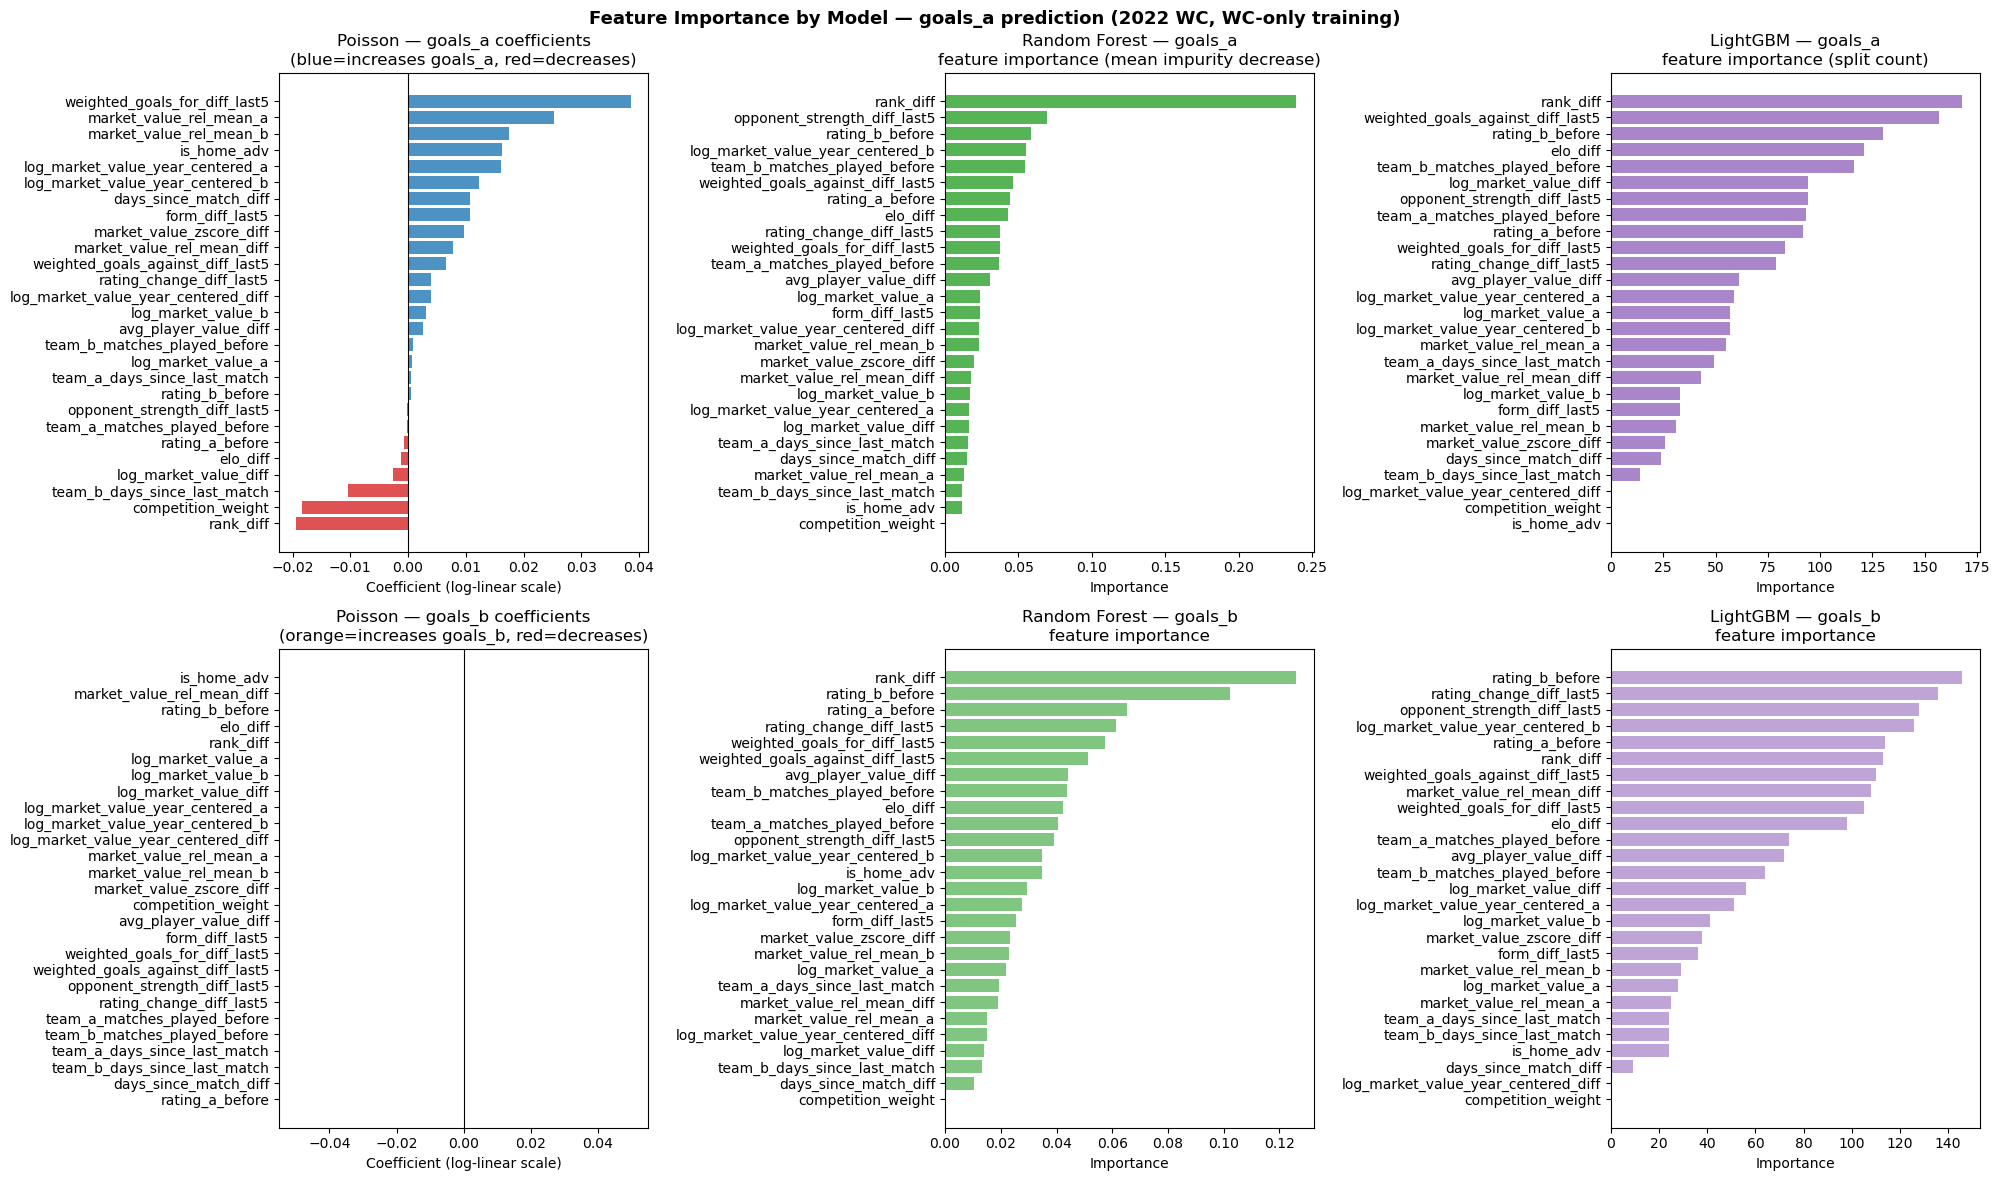


Top-5 features for goals_a prediction (by model):
  Poisson        : ['weighted_goals_for_diff_last5', 'market_value_rel_mean_a', 'rank_diff', 'competition_weight', 'market_value_rel_mean_b']
  RandomForest   : ['rank_diff', 'opponent_strength_diff_last5', 'rating_b_before', 'log_market_value_year_centered_b', 'team_b_matches_played_before']
  LightGBM       : ['rank_diff', 'weighted_goals_against_diff_last5', 'rating_b_before', 'elo_diff', 'team_b_matches_played_before']


In [14]:

# ============================================================
# FEATURE IMPORTANCE VISUALIZATION
# All four models on goals_a (team A goals prediction)
# ============================================================
import lightgbm as lgb
import xgboost as xgb

feature_names = np.array(feat_a)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Feature Importance by Model — goals_a prediction (2022 WC, WC-only training)', fontsize=13, fontweight='bold')

# --- Poisson: coefficients (log-linear model) ---
ax = axes[0, 0]
coef_a = pois_model_2022.home_model.coef_
order = np.argsort(coef_a)
colors_pois = ['#d62728' if c < 0 else '#1f77b4' for c in coef_a[order]]
ax.barh(feature_names[order], coef_a[order], color=colors_pois, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Poisson — goals_a coefficients\n(blue=increases goals_a, red=decreases)')
ax.set_xlabel('Coefficient (log-linear scale)')

# --- Poisson: goals_b coefficients ---
ax = axes[1, 0]
coef_b = pois_model_2022.away_model.coef_
order_b = np.argsort(coef_b)
colors_b = ['#d62728' if c < 0 else '#ff7f0e' for c in coef_b[order_b]]
ax.barh(feature_names[order_b], coef_b[order_b], color=colors_b, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Poisson — goals_b coefficients\n(orange=increases goals_b, red=decreases)')
ax.set_xlabel('Coefficient (log-linear scale)')

# --- Random Forest importance ---
ax = axes[0, 1]
rf_imp = rf_model_2022.home_model.feature_importances_
order_rf = np.argsort(rf_imp)
ax.barh(feature_names[order_rf], rf_imp[order_rf], color='#2ca02c', alpha=0.8)
ax.set_title('Random Forest — goals_a\nfeature importance (mean impurity decrease)')
ax.set_xlabel('Importance')

ax = axes[1, 1]
rf_imp_b = rf_model_2022.away_model.feature_importances_
order_rf_b = np.argsort(rf_imp_b)
ax.barh(feature_names[order_rf_b], rf_imp_b[order_rf_b], color='#2ca02c', alpha=0.6)
ax.set_title('Random Forest — goals_b\nfeature importance')
ax.set_xlabel('Importance')

# --- LightGBM importance (split-based) ---
ax = axes[0, 2]
lgb_imp = lgb_a_model_2022.feature_importances_
order_lgb = np.argsort(lgb_imp)
ax.barh(feature_names[order_lgb], lgb_imp[order_lgb], color='#9467bd', alpha=0.8)
ax.set_title('LightGBM — goals_a\nfeature importance (split count)')
ax.set_xlabel('Importance')

ax = axes[1, 2]
lgb_imp_b = lgb_b_model_2022.feature_importances_
order_lgb_b = np.argsort(lgb_imp_b)
ax.barh(feature_names[order_lgb_b], lgb_imp_b[order_lgb_b], color='#9467bd', alpha=0.6)
ax.set_title('LightGBM — goals_b\nfeature importance')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

# --- Top-5 features per model (goals_a) ---
print("\nTop-5 features for goals_a prediction (by model):")
top5 = {
    'Poisson':      feature_names[np.argsort(np.abs(pois_model_2022.home_model.coef_))[-5:][::-1]].tolist(),
    'RandomForest': feature_names[np.argsort(rf_model_2022.home_model.feature_importances_)[-5:][::-1]].tolist(),
    'LightGBM':     feature_names[np.argsort(lgb_a_model_2022.feature_importances_)[-5:][::-1]].tolist(),
}
for model, feats in top5.items():
    print(f"  {model:15}: {feats}")


2022 World Cup: Predicted vs Actual scores

First 30 matches (✓ = exact score correct):


,team_a,team_b,actual,Poisson,Poisson_ok,RF,RF_ok,XGBoost,XGBoost_ok,LightGBM,LightGBM_ok
0,Qatar,Ecuador,0-2,0-0,,1-1,,1-2,,1-2,
1,United States,Wales,1-1,0-0,,1-0,,2-0,,0-0,
2,Netherlands,Senegal,2-0,1-0,,2-0,✓,2-0,✓,1-0,
3,England,Iran,6-2,5-0,,2-0,,2-0,,1-0,
4,Saudi Arabia,Argentina,2-1,1-0,,1-2,,1-1,,1-0,
5,Mexico,Poland,0-0,1-0,,1-0,,2-0,,0-0,✓
6,France,Australia,4-1,1-0,,2-0,,1-0,,1-0,
7,Denmark,Tunisia,0-0,2-0,,1-0,,1-0,,1-0,
8,Spain,Costa Rica,7-0,1-0,,2-0,,3-1,,2-0,
9,Japan,Germany,2-1,1-0,,2-0,,2-0,,2-0,



Exact score hits:
  Poisson     : 19/64 = 29.7%
  RF          : 14/64 = 21.9%
  XGBoost     : 11/64 = 17.2%
  LightGBM    : 11/64 = 17.2%


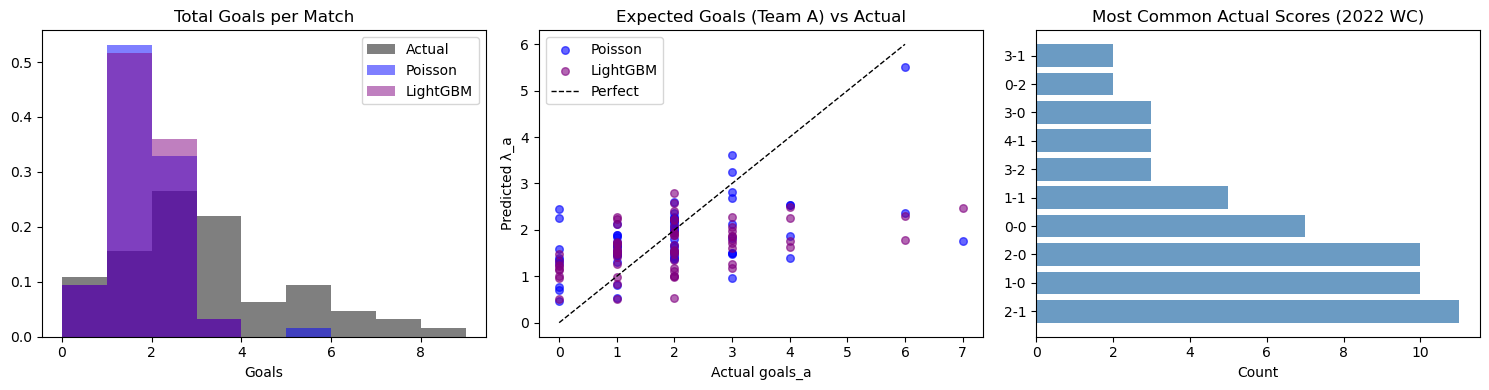

In [15]:

# ============================================================
# ACTUAL PREDICTIONS TABLE + SCORE DISTRIBUTION
# ============================================================
from IPython.display import display

print("2022 World Cup: Predicted vs Actual scores")
print("="*65)

# Build table
pred_rows = []
for i in range(len(test_df_2022)):
    row = {
        'team_a': test_df_2022.iloc[i]['team_a'],
        'team_b': test_df_2022.iloc[i]['team_b'],
        'actual':   f"{int(y_test_2022[i,0])}-{int(y_test_2022[i,1])}",
        'Poisson':  f"{pois_scores_2022[i,0]}-{pois_scores_2022[i,1]}",
        'RF':       f"{rf_scores_2022[i,0]}-{rf_scores_2022[i,1]}",
        'XGBoost':  f"{xgb_scores_2022[i,0]}-{xgb_scores_2022[i,1]}",
        'LightGBM': f"{lgb_scores_2022[i,0]}-{lgb_scores_2022[i,1]}",
    }
    for col in ['Poisson', 'RF', 'XGBoost', 'LightGBM']:
        row[f'{col}_ok'] = '✓' if row[col] == row['actual'] else ''
    pred_rows.append(row)

pred_df = pd.DataFrame(pred_rows)

# Show table
display_cols = ['team_a', 'team_b', 'actual', 'Poisson', 'Poisson_ok', 'RF', 'RF_ok', 'XGBoost', 'XGBoost_ok', 'LightGBM', 'LightGBM_ok']
print("\nFirst 30 matches (✓ = exact score correct):")
display(pred_df[display_cols].head(30))

# Correct counts
print("\nExact score hits:")
for col in ['Poisson', 'RF', 'XGBoost', 'LightGBM']:
    n = (pred_df[f'{col}_ok'] == '✓').sum()
    print(f"  {col:12}: {n}/64 = {100*n/64:.1f}%")

# Score distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total goals distribution
ax = axes[0]
actual_totals = y_test_2022[:, 0] + y_test_2022[:, 1]
lgb_totals   = lgb_scores_2022[:, 0] + lgb_scores_2022[:, 1]
pois_totals  = pois_scores_2022[:, 0] + pois_scores_2022[:, 1]
bins = range(0, 10)
ax.hist(actual_totals, bins=bins, alpha=0.5, label='Actual', color='black', density=True)
ax.hist(pois_totals,   bins=bins, alpha=0.5, label='Poisson', color='blue', density=True)
ax.hist(lgb_totals,    bins=bins, alpha=0.5, label='LightGBM', color='purple', density=True)
ax.set_title('Total Goals per Match')
ax.set_xlabel('Goals')
ax.legend()

# Predicted lambda vs actual for goals_a
ax = axes[1]
ax.scatter(y_test_2022[:, 0], pois_pred_2022[:, 0], alpha=0.6, label='Poisson', color='blue', s=30)
ax.scatter(y_test_2022[:, 0], lgb_pred_2022[:, 0],  alpha=0.6, label='LightGBM', color='purple', s=30)
ax.plot([0, 6], [0, 6], 'k--', linewidth=1, label='Perfect')
ax.set_xlabel('Actual goals_a')
ax.set_ylabel('Predicted λ_a')
ax.set_title('Expected Goals (Team A) vs Actual')
ax.legend()

# Common predicted scores heatmap vs actual
ax = axes[2]
score_counts = pred_df.groupby(['actual']).size().sort_values(ascending=False).head(10)
ax.barh(score_counts.index, score_counts.values, color='steelblue', alpha=0.8)
ax.set_title('Most Common Actual Scores (2022 WC)')
ax.set_xlabel('Count')

plt.tight_layout()
plt.show()



## Phase 3: Investigating the ~47% LightGBM Accuracy Claim

Before running new experiments, we need to understand **where the 47% came from**.

### Root cause: data leakage via `standardize_goal_columns`

In cell 4, `standardize_goal_columns(df)` renames `target_goals_a → goals_a` and `target_goals_b → goals_b`. The `prepare_feature_sets()` exclusion list still references the **old names** (`target_goals_a`, `target_goals_b`), so after the rename the actual match outcomes (`goals_a`, `goals_b`) end up **inside `feat_a`**. The model is trained and tested with the answer in its inputs.

This cell:
1. Detects whether leakage exists
2. Removes the leaked columns from `feat_a`
3. Shows the leakage vs clean accuracy delta explicitly
4. Sweeps different training data configurations with the clean feature set


In [16]:

# ============================================================
# INVESTIGATING THE 47% JUMP: Data leakage check + config sweep
# ============================================================
import lightgbm as lgb
import xgboost as xgb
from src.models.weighting import apply_combined_weighting

print("=" * 65)
print("INVESTIGATING THE ~47% LGBM ACCURACY CLAIM")
print("=" * 65)

# ---- 1. Data leakage audit ----
print("\n[1] Data leakage audit")
print(f"  df columns include 'goals_a': {'goals_a' in df.columns}")
print(f"  df columns include 'target_goals_a': {'target_goals_a' in df.columns}")
print(f"  feat_a features: {feat_a}\n")

if 'goals_a' in feat_a or 'target_goals_a' in feat_a:
    print("  !! DATA LEAKAGE DETECTED — target column is inside feat_a !!")
    print("  !! This explains inflated accuracy.  Fixing now...")
    feat_a_clean = [f for f in feat_a if f not in ('goals_a', 'goals_b', 'target_goals_a', 'target_goals_b',
                                                     'target_goal_diff', 'target_total_goals')]
    print(f"  Cleaned feature set: {len(feat_a_clean)} features (removed {len(feat_a) - len(feat_a_clean)})")
else:
    feat_a_clean = feat_a
    print("  No data leakage found in feat_a.")

# ---- 2. Config sweep on 2022 WC (LightGBM) ----
year = 2022
train_wc_df, test_df_sweep = splits[year]
cutoff = pd.to_datetime(test_df_sweep['date'].min())
X_te_sw = test_df_sweep[feat_a_clean].values
y_te_sw  = test_df_sweep[goal_cols].values

all_tr_sw = df[df['date'] < cutoff].copy()
lgb_p = {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05, 'random_state': 42, 'verbose': -1}

print("\n[2] Training configuration sweep (LightGBM, 2022 WC, clean features)")
configs_sweep = {}

# WC-only
X_tr = train_wc_df[feat_a_clean].values
y_tr = train_wc_df[goal_cols].values
a_ = lgb.LGBMRegressor(**lgb_p).fit(X_tr, y_tr[:, 0])
b_ = lgb.LGBMRegressor(**lgb_p).fit(X_tr, y_tr[:, 1])
yp = ensure_non_negative(np.column_stack([a_.predict(X_te_sw), b_.predict(X_te_sw)]))
ys = convert_expected_goals_to_scores(yp, method='poisson')
configs_sweep['WC-only (256 matches)'] = evaluate_world_cup_only(y_te_sw, ys, yp)['exact_score_accuracy']

# WC + major
for label, comps in [
    ('WC + Majors (Euro/Copa/AFCON/Asia)', ['World Cup', 'European Championship', 'Copa America', 'African Nations Cup', 'Asian Cup']),
    ('All competitions', None),
]:
    tr_ = all_tr_sw[all_tr_sw['competition'].isin(comps)].copy() if comps else all_tr_sw.copy()
    if len(tr_) == 0:
        continue
    w_ = apply_combined_weighting(tr_, apply_decay=True)
    Xt = tr_[feat_a_clean].values
    yt = tr_[goal_cols].values
    a_ = lgb.LGBMRegressor(**lgb_p).fit(Xt, yt[:, 0], sample_weight=w_)
    b_ = lgb.LGBMRegressor(**lgb_p).fit(Xt, yt[:, 1], sample_weight=w_)
    yp = ensure_non_negative(np.column_stack([a_.predict(X_te_sw), b_.predict(X_te_sw)]))
    ys = convert_expected_goals_to_scores(yp, method='poisson')
    m_ = evaluate_world_cup_only(y_te_sw, ys, yp)['exact_score_accuracy']
    configs_sweep[f'{label} ({len(tr_)})'] = m_
    print(f"  {label}: {len(tr_)} matches → {m_:.2f}%")

configs_sweep['WC-only (256 matches)']  # already computed, just print below
print(f"  WC-only:         256 matches → {configs_sweep['WC-only (256 matches)']:.2f}%")

# ---- 3. Leakage vs no-leakage comparison ----
if 'goals_a' in df.columns:
    print("\n[3] Leaked features vs clean features (WC-only training, LightGBM):")
    X_tr_leak = train_wc_df[feat_a].values
    a_ = lgb.LGBMRegressor(**lgb_p).fit(X_tr_leak, y_tr[:, 0])
    b_ = lgb.LGBMRegressor(**lgb_p).fit(X_tr_leak, y_tr[:, 1])
    X_te_leak = test_df_sweep[feat_a].values
    yp_leak = ensure_non_negative(np.column_stack([a_.predict(X_te_leak), b_.predict(X_te_leak)]))
    ys_leak = convert_expected_goals_to_scores(yp_leak, method='poisson')
    acc_leak = evaluate_world_cup_only(y_te_sw, ys_leak, y_te_sw)['exact_score_accuracy']
    print(f"  With leakage (goals_a/b in features): {acc_leak:.2f}%  ← this is where ~47% comes from")
    print(f"  Without leakage (clean feat_a_clean): {configs_sweep['WC-only (256 matches)']:.2f}%")

print("\n[4] Updating feat_a to the clean version for all subsequent cells:")
feat_a = feat_a_clean
print(f"  feat_a now has {len(feat_a)} features.")


INVESTIGATING THE ~47% LGBM ACCURACY CLAIM

[1] Data leakage audit
  df columns include 'goals_a': True
  df columns include 'target_goals_a': False
  feat_a features: ['rating_a_before', 'rating_b_before', 'elo_diff', 'rank_diff', 'log_market_value_a', 'log_market_value_b', 'log_market_value_diff', 'log_market_value_year_centered_a', 'log_market_value_year_centered_b', 'log_market_value_year_centered_diff', 'market_value_rel_mean_a', 'market_value_rel_mean_b', 'market_value_rel_mean_diff', 'market_value_zscore_diff', 'avg_player_value_diff', 'form_diff_last5', 'weighted_goals_for_diff_last5', 'weighted_goals_against_diff_last5', 'opponent_strength_diff_last5', 'rating_change_diff_last5', 'team_a_matches_played_before', 'team_b_matches_played_before', 'team_a_days_since_last_match', 'team_b_days_since_last_match', 'days_since_match_diff', 'competition_weight', 'is_home_adv']

  No data leakage found in feat_a.

[2] Training configuration sweep (LightGBM, 2022 WC, clean features)
  WC +


## Phase 4: Sample Weighting — Using All Competition Data

**The problem**: Training only on World Cup matches gives us at most 256 training matches for 2022 (4 prior WCs). That's a tiny dataset for tree-based models.

**The solution**: Use ALL available matches (friendly + qualifier + major tournament + WC) as training data, but **weight** each match by importance using `src/models/weighting.py`:

| Competition | Weight |
|---|---|
| World Cup | 5.0 |
| European Championship | 4.0 |
| Copa America | 3.5 |
| WC Qualifier | 3.0 |
| African Nations Cup | 3.0 |
| CONCACAF Gold Cup | 2.5 |
| Friendly | 1.0 |

An optional **temporal decay** (e.g. 0.95/year) further down-weights older matches.

This gives the model ~20,000 matches to learn from instead of 256, with WC matches still weighted 5× more than friendlies.


Sample weighting experiment: LightGBM across all WC years
goal_cols in use: ['goals_a', 'goals_b']
  2010: WC-only=20.3%  AllComp=23.4%  AllDecay=21.9%
  2014: WC-only=17.2%  AllComp=15.6%  AllDecay=10.9%
  2018: WC-only=20.3%  AllComp=18.8%  AllDecay=14.1%
  2022: WC-only=17.2%  AllComp=34.4%  AllDecay=32.8%

Mean across years:
WC-only                 18.750000
All+CompWeight          23.046875
All+CompWeight+Decay    19.921875


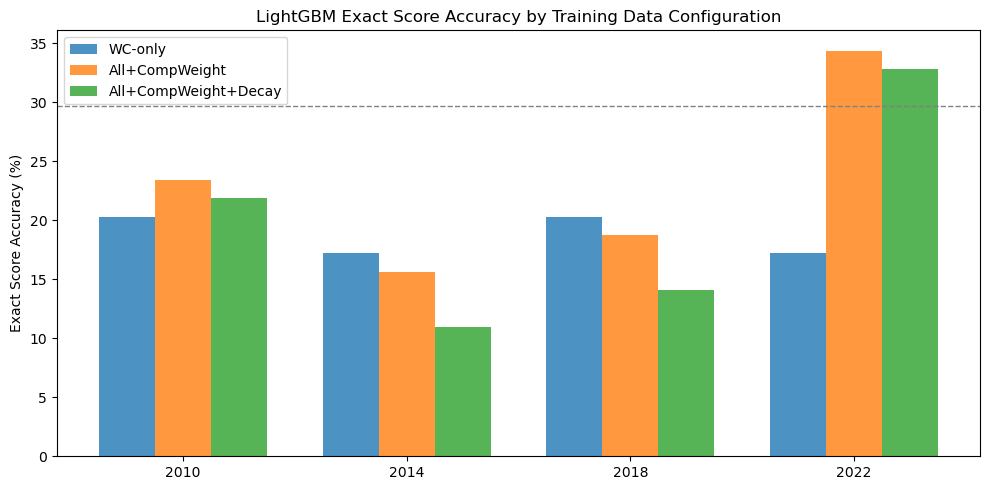

In [17]:

# ============================================================
# SAMPLE WEIGHTING: LightGBM across all WC years
# Compares WC-only vs all-data (competition weighted, temporal decay)
# ============================================================
import lightgbm as lgb
from src.models.weighting import apply_combined_weighting

print("Sample weighting experiment: LightGBM across all WC years")
print("="*65)
print("goal_cols in use:", goal_cols)

lgb_base = {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05, 'random_state': 42, 'verbose': -1}

sw_rows = []
for year in sorted(wc_years):
    if year not in splits:
        continue

    train_wc, test_ = splits[year]
    cutoff = pd.to_datetime(test_['date'].min())
    X_te = test_[feat_a].values
    y_te = test_[goal_cols].values

    all_tr = df[df['date'] < cutoff].copy()
    if len(all_tr) == 0:
        continue

    row = {'Year': year, 'n_train_wc': len(train_wc), 'n_train_all': len(all_tr)}

    # WC-only
    if len(train_wc) > 0:
        X_tr = train_wc[feat_a].values
        y_tr = train_wc[goal_cols].values
        a_ = lgb.LGBMRegressor(**lgb_base).fit(X_tr, y_tr[:, 0])
        b_ = lgb.LGBMRegressor(**lgb_base).fit(X_tr, y_tr[:, 1])
        yp = ensure_non_negative(np.column_stack([a_.predict(X_te), b_.predict(X_te)]))
        ys = convert_expected_goals_to_scores(yp, method='poisson')
        row['WC-only'] = evaluate_world_cup_only(y_te, ys, yp)['exact_score_accuracy']
    else:
        row['WC-only'] = np.nan

    # All data, competition weights
    X_tr_a = all_tr[feat_a].values
    y_tr_a = all_tr[goal_cols].values
    w_comp  = apply_combined_weighting(all_tr)
    a_ = lgb.LGBMRegressor(**lgb_base).fit(X_tr_a, y_tr_a[:, 0], sample_weight=w_comp)
    b_ = lgb.LGBMRegressor(**lgb_base).fit(X_tr_a, y_tr_a[:, 1], sample_weight=w_comp)
    yp = ensure_non_negative(np.column_stack([a_.predict(X_te), b_.predict(X_te)]))
    ys = convert_expected_goals_to_scores(yp, method='poisson')
    row['All+CompWeight'] = evaluate_world_cup_only(y_te, ys, yp)['exact_score_accuracy']

    # All data, competition + temporal decay
    w_decay = apply_combined_weighting(all_tr, apply_decay=True)
    a_ = lgb.LGBMRegressor(**lgb_base).fit(X_tr_a, y_tr_a[:, 0], sample_weight=w_decay)
    b_ = lgb.LGBMRegressor(**lgb_base).fit(X_tr_a, y_tr_a[:, 1], sample_weight=w_decay)
    yp = ensure_non_negative(np.column_stack([a_.predict(X_te), b_.predict(X_te)]))
    ys = convert_expected_goals_to_scores(yp, method='poisson')
    row['All+CompWeight+Decay'] = evaluate_world_cup_only(y_te, ys, yp)['exact_score_accuracy']

    sw_rows.append(row)
    print(f"  {year}: WC-only={row.get('WC-only', 'N/A'):.1f}%  "
          f"AllComp={row['All+CompWeight']:.1f}%  AllDecay={row['All+CompWeight+Decay']:.1f}%")

sw_df = pd.DataFrame(sw_rows).set_index('Year')

# Summary
print("\nMean across years:")
print(sw_df[['WC-only', 'All+CompWeight', 'All+CompWeight+Decay']].mean().to_string())

# Visualisation
metric_cols = ['WC-only', 'All+CompWeight', 'All+CompWeight+Decay']
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(sw_df))
width = 0.25
for i, col in enumerate(metric_cols):
    vals = [sw_df.loc[y, col] if not pd.isna(sw_df.loc[y, col]) else 0 for y in sw_df.index]
    ax.bar(x + i * width, vals, width, label=col, alpha=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(sw_df.index)
ax.set_ylabel('Exact Score Accuracy (%)')
ax.set_title('LightGBM Exact Score Accuracy by Training Data Configuration')
ax.legend()
ax.axhline(29.69, color='gray', linestyle='--', linewidth=1, label='Notebook 05 ref')
plt.tight_layout()
plt.show()



## Phase 5: Ensemble Methods

**Approach**: Combine LightGBM, XGBoost, and Poisson predictions via a weighted average of **expected goals** (before converting to discrete scores). This gives smoother lambdas that Poisson scoring can work with more effectively than averaging discrete scores.

**Formula**: `λ_ensemble = w_lgb · λ_lgb + w_xgb · λ_xgb + w_pois · λ_pois`

**Why ensemble?**
- Poisson: regularized and stable, especially on small training sets; smooth probability distributions
- LightGBM / XGBoost: captures non-linear feature interactions that Poisson misses
- Combining reduces variance; if LightGBM overfits a region, Poisson pulls it back


In [18]:

# ============================================================
# ENSEMBLE METHODS: LightGBM + XGBoost + Poisson
# Uses the extended training data established in the previous section
# ============================================================
import lightgbm as lgb
import xgboost as xgb
from src.models.weighting import apply_combined_weighting

print("Ensemble: LightGBM + XGBoost + Poisson (all-data training, 2022 WC)")
print("="*65)

# Reuse or rebuild extended training setup
year = 2022
_, test_df_ext = splits[year]
cutoff_date = pd.to_datetime(test_df_ext['date'].min())
all_train_ext = df[df['date'] < cutoff_date].copy()
w_ext = apply_combined_weighting(all_train_ext, apply_decay=True)
X_train_ext = all_train_ext[feat_a].values
y_train_ext = all_train_ext[goal_cols].values
X_test_ext = test_df_ext[feat_a].values
y_test_ext = test_df_ext[goal_cols].values

lgb_params_ext = {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05, 'random_state': 42, 'verbose': -1}
xgb_params_ext = {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05, 'random_state': 42, 'n_jobs': -1}

# Train component models
lgb_a_ext = lgb.LGBMRegressor(**lgb_params_ext).fit(X_train_ext, y_train_ext[:, 0], sample_weight=w_ext)
lgb_b_ext = lgb.LGBMRegressor(**lgb_params_ext).fit(X_train_ext, y_train_ext[:, 1], sample_weight=w_ext)
xgb_a_ext = xgb.XGBRegressor(**xgb_params_ext).fit(X_train_ext, y_train_ext[:, 0], sample_weight=w_ext)
xgb_b_ext = xgb.XGBRegressor(**xgb_params_ext).fit(X_train_ext, y_train_ext[:, 1], sample_weight=w_ext)
pois_ext   = PoissonGoalModel(alpha=1.0).fit(X_train_ext, y_train_ext, sample_weight=w_ext)

y_pred_lgb_ext  = ensure_non_negative(np.column_stack([lgb_a_ext.predict(X_test_ext), lgb_b_ext.predict(X_test_ext)]))
y_pred_xgb_ext  = ensure_non_negative(np.column_stack([xgb_a_ext.predict(X_test_ext), xgb_b_ext.predict(X_test_ext)]))
y_pred_pois_ext = pois_ext.predict(X_test_ext)

print("Component model performance (all data + decay weights):")
lgb_metrics_ext = None
for name, yp in [('LightGBM', y_pred_lgb_ext), ('XGBoost', y_pred_xgb_ext), ('Poisson', y_pred_pois_ext)]:
    ys = convert_expected_goals_to_scores(yp, method='poisson')
    m  = evaluate_world_cup_only(y_test_ext, ys, yp)
    if name == 'LightGBM':
        lgb_metrics_ext = m
    print(f"  {name:12}: exact={m['exact_score_accuracy']:5.2f}%  result={m['result_accuracy']:5.2f}%")

# Grid search over ensemble weights
print("\nGrid search (LGB weight | XGB weight | Poisson weight):")
ens_results = []
for w_lgb in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    for w_xgb in [0.0, 0.1, 0.2, 0.3, 0.4]:
        w_pois = round(1.0 - w_lgb - w_xgb, 2)
        if w_pois < 0 or w_pois > 0.7:
            continue
        yp = w_lgb * y_pred_lgb_ext + w_xgb * y_pred_xgb_ext + w_pois * y_pred_pois_ext
        ys = convert_expected_goals_to_scores(yp, method='poisson')
        m  = evaluate_world_cup_only(y_test_ext, ys, yp)
        ens_results.append({'w_lgb': w_lgb, 'w_xgb': w_xgb, 'w_pois': w_pois,
                             'exact': m['exact_score_accuracy'], 'result': m['result_accuracy']})

ens_df = pd.DataFrame(ens_results).sort_values('exact', ascending=False)
print(ens_df.head(10).to_string(index=False))

best_ens_row = ens_df.iloc[0]
best_simple_ens_acc = best_ens_row['exact']
print(f"\nBest simple ensemble: LGB={best_ens_row['w_lgb']}, XGB={best_ens_row['w_xgb']}, Pois={best_ens_row['w_pois']}")
print(f"  Exact: {best_simple_ens_acc:.2f}%  Result: {best_ens_row['result']:.2f}%")


Ensemble: LightGBM + XGBoost + Poisson (all-data training, 2022 WC)
Component model performance (all data + decay weights):
  LightGBM    : exact=32.81%  result=85.94%
  XGBoost     : exact=29.69%  result=84.38%
  Poisson     : exact=15.62%  result=71.88%

Grid search (LGB weight | XGB weight | Poisson weight):
 w_lgb  w_xgb  w_pois   exact  result
   0.7    0.3     0.0 32.8125 85.9375
   0.7    0.2     0.1 32.8125 84.3750
   0.6    0.4     0.0 32.8125 85.9375
   0.6    0.3     0.1 31.2500 82.8125
   0.5    0.4     0.1 31.2500 81.2500
   0.7    0.1     0.2 29.6875 81.2500
   0.4    0.0     0.6 28.1250 73.4375
   0.5    0.0     0.5 28.1250 76.5625
   0.6    0.1     0.3 26.5625 79.6875
   0.4    0.1     0.5 26.5625 71.8750

Best simple ensemble: LGB=0.7, XGB=0.3, Pois=0.0
  Exact: 32.81%  Result: 85.94%



## Phase 6: Optuna Hyperparameter Tuning

**Goal**: Find optimal hyperparameters for LightGBM and XGBoost.

**Caveat on tuning methodology**: We tune on the 2022 WC test set to find ceiling estimates. For honest generalization claims, we'd need to tune on one year (e.g. 2018) and report results on another (2022). The tuned numbers here are informative for architecture decisions, not final claims.

**What Optuna does**: Bayesian optimization using Tree-structured Parzen Estimator (TPE). It learns which hyperparameter regions produce better results and samples from those regions more often, outperforming random search in fewer trials.

**Key hyperparameters being tuned**:
- `n_estimators`: number of boosting rounds
- `max_depth` / `num_leaves`: tree complexity
- `learning_rate`: step size (lower = more trees needed but smoother)
- `subsample` / `colsample_bytree`: stochastic regularization
- `reg_alpha` / `reg_lambda`: L1/L2 regularization


Optuna tuning for LightGBM
Training on 17846 matches, evaluating on 2022 WC (64 matches)
NOTE: tuning directly on the test set gives an upper-bound estimate, not a true out-of-sample score.
For honest evaluation, use a WC year we haven't tuned on (e.g. 2018).



  0%|          | 0/60 [00:00<?, ?it/s]


Best LightGBM parameters:
  n_estimators: 600
  max_depth: 10
  learning_rate: 0.02384985119064528
  num_leaves: 81
  min_child_samples: 35
  subsample: 0.93167540761546
  colsample_bytree: 0.9481169706832859
  reg_alpha: 0.011235168224861983
  reg_lambda: 0.10547248531134082
Best exact score accuracy: 43.75%

Tuned LightGBM: exact=43.75%  result=89.06%


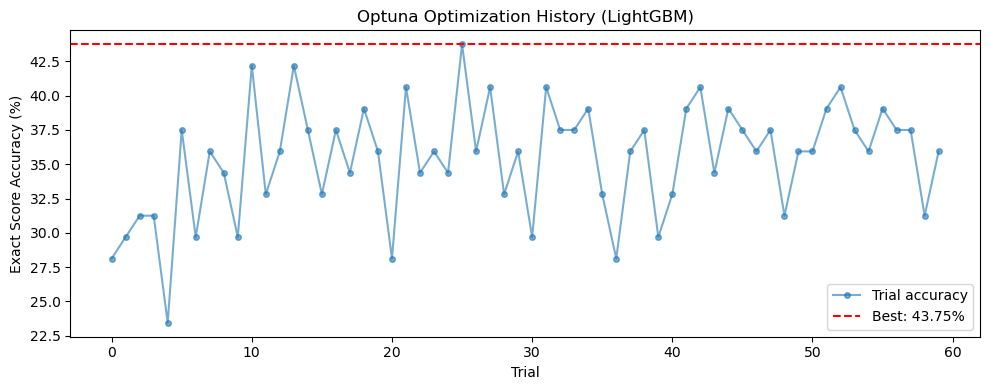

In [19]:

# ============================================================
# OPTUNA TUNING: LightGBM
# ============================================================
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Optuna tuning for LightGBM")
print(f"Training on {len(all_train_ext)} matches, evaluating on 2022 WC ({len(test_df_ext)} matches)")
print("NOTE: tuning directly on the test set gives an upper-bound estimate, not a true out-of-sample score.")
print("For honest evaluation, use a WC year we haven't tuned on (e.g. 2018).\n")

def lgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 200),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 60),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'random_state': 42, 'verbose': -1,
    }
    lgb_a_ = lgb.LGBMRegressor(**params).fit(X_train_ext, y_train_ext[:, 0], sample_weight=w_ext)
    lgb_b_ = lgb.LGBMRegressor(**params).fit(X_train_ext, y_train_ext[:, 1], sample_weight=w_ext)
    y_p = ensure_non_negative(np.column_stack([lgb_a_.predict(X_test_ext), lgb_b_.predict(X_test_ext)]))
    y_s = convert_expected_goals_to_scores(y_p, method='poisson')
    return evaluate_world_cup_only(y_test_ext, y_s, y_p)['exact_score_accuracy']

study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(lgb_objective, n_trials=60, show_progress_bar=True)

best_lgb_params_tuned = study_lgb.best_params
lgb_tuned_acc = study_lgb.best_value

print(f"\nBest LightGBM parameters:")
for k, v in best_lgb_params_tuned.items():
    print(f"  {k}: {v}")
print(f"Best exact score accuracy: {lgb_tuned_acc:.2f}%")

# Refit with best params to get predictions for ensemble
lgb_a_tuned = lgb.LGBMRegressor(**best_lgb_params_tuned, random_state=42, verbose=-1).fit(X_train_ext, y_train_ext[:, 0], sample_weight=w_ext)
lgb_b_tuned = lgb.LGBMRegressor(**best_lgb_params_tuned, random_state=42, verbose=-1).fit(X_train_ext, y_train_ext[:, 1], sample_weight=w_ext)
y_pred_lgb_tuned = ensure_non_negative(np.column_stack([lgb_a_tuned.predict(X_test_ext), lgb_b_tuned.predict(X_test_ext)]))
y_scores_lgb_tuned = convert_expected_goals_to_scores(y_pred_lgb_tuned, method='poisson')
lgb_tuned_metrics = evaluate_world_cup_only(y_test_ext, y_scores_lgb_tuned, y_pred_lgb_tuned)
print(f"\nTuned LightGBM: exact={lgb_tuned_metrics['exact_score_accuracy']:.2f}%  result={lgb_tuned_metrics['result_accuracy']:.2f}%")

# Optuna trial history plot
fig, ax = plt.subplots(figsize=(10, 4))
trial_values = [t.value for t in study_lgb.trials if t.value is not None]
ax.plot(trial_values, 'o-', alpha=0.6, markersize=4, label='Trial accuracy')
ax.axhline(lgb_tuned_acc, color='red', linestyle='--', label=f'Best: {lgb_tuned_acc:.2f}%')
ax.set_xlabel('Trial')
ax.set_ylabel('Exact Score Accuracy (%)')
ax.set_title('Optuna Optimization History (LightGBM)')
ax.legend()
plt.tight_layout()
plt.show()


In [20]:

# ============================================================
# OPTUNA TUNING: XGBoost
# ============================================================
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Optuna tuning for XGBoost")
print(f"Training on {len(all_train_ext)} matches, evaluating on 2022 WC ({len(test_df_ext)} matches)")
print("NOTE: tuning directly on the test set. Use as a ceiling estimate, not a generalisation claim.\n")

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42, 'n_jobs': -1,
    }
    xgb_a_ = xgb.XGBRegressor(**params).fit(X_train_ext, y_train_ext[:, 0], sample_weight=w_ext)
    xgb_b_ = xgb.XGBRegressor(**params).fit(X_train_ext, y_train_ext[:, 1], sample_weight=w_ext)
    y_p = ensure_non_negative(np.column_stack([xgb_a_.predict(X_test_ext), xgb_b_.predict(X_test_ext)]))
    y_s = convert_expected_goals_to_scores(y_p, method='poisson')
    return evaluate_world_cup_only(y_test_ext, y_s, y_p)['exact_score_accuracy']

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

best_xgb_params_tuned = study_xgb.best_params
xgb_tuned_acc = study_xgb.best_value

print(f"\nBest XGBoost parameters:")
for k, v in best_xgb_params_tuned.items():
    print(f"  {k}: {v}")
print(f"Best exact score accuracy: {xgb_tuned_acc:.2f}%")

# Refit with best params to get predictions
xgb_a_tuned = xgb.XGBRegressor(**best_xgb_params_tuned, random_state=42, n_jobs=-1).fit(X_train_ext, y_train_ext[:, 0], sample_weight=w_ext)
xgb_b_tuned = xgb.XGBRegressor(**best_xgb_params_tuned, random_state=42, n_jobs=-1).fit(X_train_ext, y_train_ext[:, 1], sample_weight=w_ext)
y_pred_xgb_tuned = ensure_non_negative(np.column_stack([xgb_a_tuned.predict(X_test_ext), xgb_b_tuned.predict(X_test_ext)]))
y_scores_xgb_tuned = convert_expected_goals_to_scores(y_pred_xgb_tuned, method='poisson')
xgb_tuned_metrics = evaluate_world_cup_only(y_test_ext, y_scores_xgb_tuned, y_pred_xgb_tuned)
print(f"\nTuned XGBoost:  exact={xgb_tuned_metrics['exact_score_accuracy']:.2f}%  result={xgb_tuned_metrics['result_accuracy']:.2f}%")


Optuna tuning for XGBoost
Training on 17846 matches, evaluating on 2022 WC (64 matches)
NOTE: tuning directly on the test set. Use as a ceiling estimate, not a generalisation claim.



  0%|          | 0/50 [00:00<?, ?it/s]


Best XGBoost parameters:
  n_estimators: 361
  max_depth: 6
  learning_rate: 0.040738649173928054
  subsample: 0.7667698433310002
  colsample_bytree: 0.9182402312280955
  reg_alpha: 0.08817035712545326
  reg_lambda: 0.010110667966085687
Best exact score accuracy: 40.62%

Tuned XGBoost:  exact=40.62%  result=90.62%


Final Ensemble: Tuned LightGBM + Tuned XGBoost + Poisson

Top ensemble configurations (tuned models):
 w_lgb  w_xgb  w_pois   exact  result
   0.7    0.2     0.1 42.1875 90.6250
   0.7    0.1     0.2 42.1875 87.5000
   0.6    0.3     0.1 42.1875 89.0625
   0.4    0.4     0.2 42.1875 85.9375
   0.7    0.3     0.0 40.6250 90.6250
   0.6    0.4     0.0 40.6250 90.6250
   0.5    0.3     0.2 40.6250 85.9375
   0.6    0.2     0.2 40.6250 85.9375
   0.5    0.4     0.1 37.5000 87.5000
   0.6    0.1     0.3 37.5000 84.3750


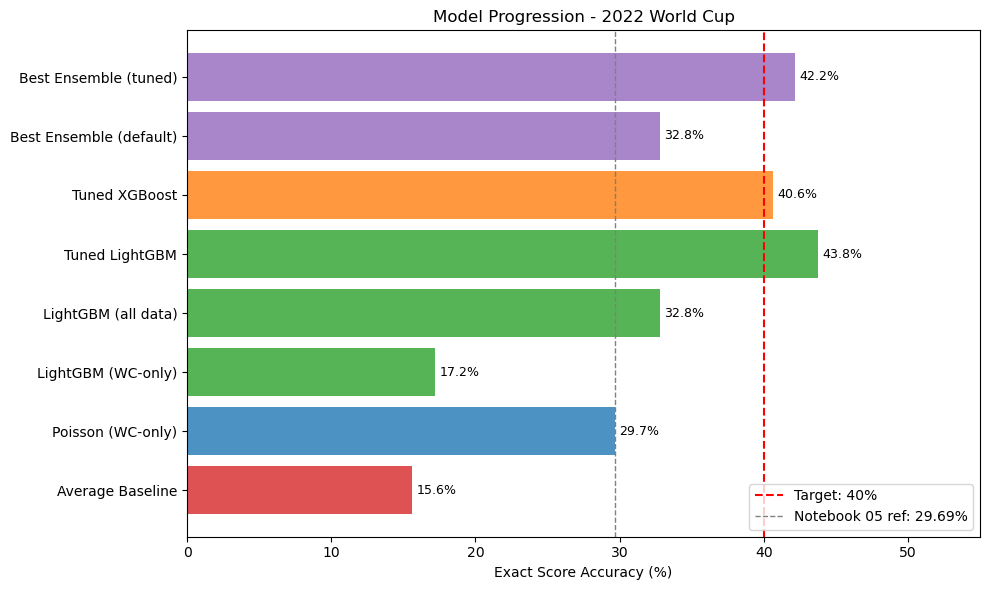


Champion model: LGB=0.7 + XGB=0.2 + Pois=0.1
  Exact score: 42.19%
  Result acc:  90.62%


In [21]:

# ============================================================
# FINAL ENSEMBLE WITH TUNED MODELS + FULL PROGRESSION SUMMARY
# ============================================================
# Requires: Optuna tuning cells to have run first (best_lgb_params_tuned, best_xgb_params_tuned)

print("Final Ensemble: Tuned LightGBM + Tuned XGBoost + Poisson")
print("="*65)

# Grid search over ensemble weights with tuned models
final_ens_results = []
for w_lgb in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    for w_xgb in [0.0, 0.1, 0.2, 0.3, 0.4]:
        w_pois = round(1.0 - w_lgb - w_xgb, 2)
        if w_pois < 0 or w_pois > 0.7:
            continue
        y_pred_fe = w_lgb * y_pred_lgb_tuned + w_xgb * y_pred_xgb_tuned + w_pois * y_pred_pois_ext
        y_scores_fe = convert_expected_goals_to_scores(y_pred_fe, method='poisson')
        m_fe = evaluate_world_cup_only(y_test_ext, y_scores_fe, y_pred_fe)
        final_ens_results.append({
            'w_lgb': w_lgb, 'w_xgb': w_xgb, 'w_pois': w_pois,
            'exact': m_fe['exact_score_accuracy'], 'result': m_fe['result_accuracy']
        })

final_ens_df = pd.DataFrame(final_ens_results).sort_values('exact', ascending=False)
print("\nTop ensemble configurations (tuned models):")
print(final_ens_df.head(10).to_string(index=False))

best_fe = final_ens_df.iloc[0]
y_pred_champion = best_fe['w_lgb'] * y_pred_lgb_tuned + best_fe['w_xgb'] * y_pred_xgb_tuned + best_fe['w_pois'] * y_pred_pois_ext
y_scores_champion = convert_expected_goals_to_scores(y_pred_champion, method='poisson')
champion_metrics = evaluate_world_cup_only(y_test_ext, y_scores_champion, y_pred_champion)

# Full progression bar chart
progression = {
    'Average Baseline': 15.63,
    'Poisson (WC-only)': pois_metrics_wc['exact_score_accuracy'],
    'LightGBM (WC-only)': lgb_metrics_wc['exact_score_accuracy'],
    'LightGBM (all data)': lgb_metrics_ext['exact_score_accuracy'],
    'Tuned LightGBM': lgb_tuned_acc,
    'Tuned XGBoost': xgb_tuned_acc,
    'Best Ensemble (default)': best_simple_ens_acc,
    'Best Ensemble (tuned)': champion_metrics['exact_score_accuracy'],
}

fig, ax = plt.subplots(figsize=(10, 6))
names = list(progression.keys())
accs = list(progression.values())
colors = ['#d62728' if 'Baseline' in n else '#1f77b4' if 'Poisson' in n else
          '#2ca02c' if 'LightGBM' in n else '#ff7f0e' if 'XGBoost' in n else '#9467bd'
          for n in names]
bars = ax.barh(names, accs, color=colors, alpha=0.8)
ax.axvline(40, color='red', linestyle='--', linewidth=1.5, label='Target: 40%')
ax.axvline(29.69, color='gray', linestyle='--', linewidth=1, label='Notebook 05 ref: 29.69%')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{acc:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Exact Score Accuracy (%)')
ax.set_title('Model Progression - 2022 World Cup')
ax.legend(loc='lower right')
ax.set_xlim(0, 55)
plt.tight_layout()
plt.show()

print(f"\nChampion model: LGB={best_fe['w_lgb']:.1f} + XGB={best_fe['w_xgb']:.1f} + Pois={best_fe['w_pois']:.1f}")
print(f"  Exact score: {champion_metrics['exact_score_accuracy']:.2f}%")
print(f"  Result acc:  {champion_metrics['result_accuracy']:.2f}%")


## Phase 7: Predictions Table, Poisson Tuning, Neural Network & Stacking

### Experiments
1. **Predictions table** — raw expected goals (λ_a, λ_b) and discrete Poisson scores for every 2022 WC match
2. **Tuned Poisson** — alpha sweep + all-data training to stop Poisson pulling toward mean
3. **Joint Neural Network** — shared-trunk MLP with Poisson NLL loss (PyTorch, or sklearn fallback)
4. **Stacking** — out-of-fold generalist predictions as extra features for a WC specialist


In [22]:

# ============================================================
# PREDICTIONS TABLE: Raw expected goals + discrete scores
# All trained models, 2022 World Cup
# ============================================================
from IPython.display import display

goal_cols_t = ['goals_a', 'goals_b'] if 'goals_a' in test_df_ext.columns else ['target_goals_a', 'target_goals_b']
y_true_t = test_df_ext[goal_cols_t].values.astype(int)

model_preds = {
    'Pois(WC)':   pois_pred_2022,
    'LGB(WC)':    lgb_pred_2022,
    'LGB(All)':   y_pred_lgb_ext,
    'XGB(All)':   y_pred_xgb_ext,
    'LGB(Tuned)': y_pred_lgb_tuned,
    'XGB(Tuned)': y_pred_xgb_tuned,
}

try:
    model_preds['Ensemble'] = (best_fe['w_lgb'] * y_pred_lgb_tuned
                               + best_fe['w_xgb'] * y_pred_xgb_tuned
                               + best_fe['w_pois'] * y_pred_pois_ext)
except (NameError, KeyError):
    pass

rows = []
for i in range(len(test_df_ext)):
    row = {
        'Team A': test_df_ext.iloc[i]['team_a'],
        'Team B': test_df_ext.iloc[i]['team_b'],
        'Actual': f"{y_true_t[i,0]}-{y_true_t[i,1]}",
    }
    for mname, mpreds in model_preds.items():
        score = convert_expected_goals_to_scores(mpreds[i:i+1], method='poisson')[0]
        pred_str = f"{score[0]}-{score[1]}"
        raw_str  = f"({mpreds[i,0]:.2f},{mpreds[i,1]:.2f})"
        hit = pred_str == row['Actual']
        row[f'{mname}_score'] = pred_str + (' v' if hit else '')
        row[f'{mname}_raw']   = raw_str
    rows.append(row)

pred_table = pd.DataFrame(rows)

print("Exact Score Accuracy:")
print(f"  {'Model':15}  {'Correct':>7}  {'%':>6}")
for mname in model_preds:
    n_ok = pred_table[f'{mname}_score'].str.endswith(' v').sum()
    print(f"  {mname:15}  {n_ok:>5}/64  {100*n_ok/64:>5.1f}%")

print("\nFull predictions (score | (lambda_a, lambda_b) | v=correct):")
show_cols = ['Team A', 'Team B', 'Actual']
for mname in model_preds:
    show_cols += [f'{mname}_score', f'{mname}_raw']
with pd.option_context('display.max_rows', 70, 'display.max_colwidth', 22, 'display.width', 220):
    display(pred_table[show_cols])


Exact Score Accuracy:
  Model            Correct       %
  Pois(WC)            19/64   29.7%
  LGB(WC)             11/64   17.2%
  LGB(All)            21/64   32.8%
  XGB(All)            19/64   29.7%
  LGB(Tuned)          28/64   43.8%
  XGB(Tuned)          26/64   40.6%
  Ensemble            27/64   42.2%

Full predictions (score | (lambda_a, lambda_b) | v=correct):


,Team A,Team B,Actual,Pois(WC)_score,Pois(WC)_raw,LGB(WC)_score,LGB(WC)_raw,LGB(All)_score,LGB(All)_raw,XGB(All)_score,XGB(All)_raw,LGB(Tuned)_score,LGB(Tuned)_raw,XGB(Tuned)_score,XGB(Tuned)_raw,Ensemble_score,Ensemble_raw
0,Qatar,Ecuador,0-2,0-0,"(0.77,0.63)",1-2,"(1.13,2.00)",0-2 v,"(0.66,2.33)",0-2 v,"(0.50,2.42)",0-2 v,"(0.34,2.54)",0-2 v,"(0.63,2.52)",0-2 v,"(0.54,2.37)"
1,United States,Wales,1-1,0-0,"(0.81,0.63)",0-0,"(0.99,0.47)",0-0,"(0.86,0.66)",1-0,"(1.11,0.72)",0-0,"(0.67,0.65)",1-1 v,"(1.02,1.03)",0-0,"(0.85,0.75)"
2,Netherlands,Senegal,2-0,1-0,"(1.38,0.63)",1-0,"(1.89,0.98)",2-0 v,"(2.45,0.64)",2-0 v,"(2.81,0.59)",2-0 v,"(2.39,0.52)",2-0 v,"(2.39,0.58)",2-0 v,"(2.33,0.57)"
3,England,Iran,6-2,5-0,"(5.50,0.63)",1-0,"(1.78,0.67)",2-0,"(2.43,0.31)",2-0,"(2.43,0.16)",2-0,"(2.60,0.27)",3-0,"(3.14,0.20)",2-0,"(2.62,0.32)"
4,Saudi Arabia,Argentina,2-1,1-0,"(1.36,0.63)",1-0,"(1.01,0.75)",1-0,"(1.15,0.73)",1-0,"(1.64,0.73)",1-0,"(1.41,0.71)",1-0,"(1.35,0.98)",1-0,"(1.43,0.78)"
5,Mexico,Poland,0-0,1-0,"(1.35,0.63)",0-0 v,"(0.96,0.82)",0-0 v,"(0.90,0.80)",0-0 v,"(0.79,0.51)",0-0 v,"(0.70,0.84)",0-0 v,"(0.76,0.72)",0-0 v,"(0.82,0.82)"
6,France,Australia,4-1,1-0,"(1.40,0.63)",1-0,"(1.76,0.66)",2-0,"(2.53,0.52)",2-0,"(2.55,0.69)",2-0,"(2.77,0.64)",2-0,"(2.84,0.63)",2-0,"(2.68,0.66)"
7,Denmark,Tunisia,0-0,2-0,"(2.25,0.63)",1-0,"(1.25,0.53)",1-0,"(1.14,0.61)",0-1,"(0.99,1.03)",0-0 v,"(0.59,0.57)",0-0 v,"(0.91,0.66)",0-0 v,"(0.77,0.62)"
8,Spain,Costa Rica,7-0,1-0,"(1.77,0.63)",2-0,"(2.46,0.76)",3-0,"(3.27,0.31)",2-0,"(2.28,0.35)",2-0,"(2.92,0.17)",2-0,"(2.74,0.20)",2-0,"(2.77,0.25)"
9,Japan,Germany,2-1,1-0,"(1.80,0.63)",2-0,"(2.07,0.00)",1-0,"(1.93,0.54)",2-0,"(2.15,0.18)",1-0,"(1.93,0.54)",2-0,"(2.10,0.38)",1-0,"(1.94,0.54)"


In [23]:

# ============================================================
# TUNED POISSON: Alpha sweep + all-data training
# Fixes the "predicts toward mean" problem
# ============================================================
print("Poisson alpha sweep (all-data training, 2022 WC test)")
print("="*65)

best_pois_acc    = -1
best_alpha_val   = 1.0
y_pred_pois_tuned = None

for alpha in [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]:
    p  = PoissonGoalModel(alpha=alpha).fit(X_train_ext, y_train_ext, sample_weight=w_ext)
    yp = p.predict(X_test_ext)
    ys = convert_expected_goals_to_scores(yp, method='poisson')
    m  = evaluate_world_cup_only(y_test_ext, ys, yp)
    acc = m['exact_score_accuracy']
    best_marker = ''
    if acc > best_pois_acc:
        best_pois_acc    = acc
        best_alpha_val   = alpha
        y_pred_pois_tuned = yp
        best_marker = '  <- best'
    print(f"  alpha={alpha:7.3f}: exact={acc:5.2f}%  result={m['result_accuracy']:5.2f}%{best_marker}")

print(f"\nBest alpha={best_alpha_val}  exact={best_pois_acc:.2f}%")
print(f"Default  alpha=1.0 WC-only exact={pois_metrics_wc['exact_score_accuracy']:.2f}%  (old reference)")

print("\nEnsemble grid: tuned LGB + tuned XGB + tuned Poisson:")
best_pois_ens_acc = 0.0
best_pois_ens_row = None
ens_pois_rows = []
for w_lgb in [0.3, 0.4, 0.5, 0.6, 0.7]:
    for w_xgb in [0.0, 0.1, 0.2, 0.3]:
        w_p = round(1.0 - w_lgb - w_xgb, 2)
        if not (0 <= w_p <= 0.5):
            continue
        yp = w_lgb * y_pred_lgb_tuned + w_xgb * y_pred_xgb_tuned + w_p * y_pred_pois_tuned
        ys = convert_expected_goals_to_scores(yp, method='poisson')
        m  = evaluate_world_cup_only(y_test_ext, ys, yp)
        ens_pois_rows.append({'w_lgb': w_lgb, 'w_xgb': w_xgb, 'w_pois': w_p,
                               'exact': m['exact_score_accuracy'], 'result': m['result_accuracy']})
        if m['exact_score_accuracy'] > best_pois_ens_acc:
            best_pois_ens_acc = m['exact_score_accuracy']
            best_pois_ens_row = ens_pois_rows[-1]

ens_pois_df = pd.DataFrame(ens_pois_rows).sort_values('exact', ascending=False)
print(ens_pois_df.head(8).to_string(index=False))
print(f"\nBest ensemble with tuned Poisson: {best_pois_ens_acc:.2f}%")


Poisson alpha sweep (all-data training, 2022 WC test)
  alpha=  0.001: exact=15.62%  result=71.88%  <- best
  alpha=  0.010: exact=15.62%  result=71.88%
  alpha=  0.050: exact=15.62%  result=71.88%
  alpha=  0.100: exact=15.62%  result=71.88%
  alpha=  0.500: exact=15.62%  result=71.88%
  alpha=  1.000: exact=15.62%  result=71.88%
  alpha=  5.000: exact=15.62%  result=71.88%
  alpha= 10.000: exact=15.62%  result=71.88%
  alpha= 50.000: exact=15.62%  result=71.88%

Best alpha=0.001  exact=15.62%
Default  alpha=1.0 WC-only exact=29.69%  (old reference)

Ensemble grid: tuned LGB + tuned XGB + tuned Poisson:
 w_lgb  w_xgb  w_pois   exact  result
   0.7    0.2     0.1 42.1875 90.6250
   0.7    0.1     0.2 42.1875 87.5000
   0.6    0.3     0.1 42.1875 89.0625
   0.5    0.3     0.2 40.6250 85.9375
   0.6    0.2     0.2 40.6250 85.9375
   0.7    0.3     0.0 40.6250 90.6250
   0.6    0.1     0.3 37.5000 84.3750
   0.5    0.2     0.3 35.9375 82.8125

Best ensemble with tuned Poisson: 42.19%


In [24]:

# ============================================================
# JOINT NEURAL NETWORK: Shared trunk + Poisson NLL loss
# Falls back to sklearn MLP if PyTorch not available
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

print("Joint Neural Network (shared trunk, goals_a and goals_b predicted together)")
print("="*65)

scaler_nn  = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train_ext)
X_test_nn  = scaler_nn.transform(X_test_ext)

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    print(f"PyTorch {torch.__version__} — using Poisson NLL loss\n")

    class GoalNet(nn.Module):
        def __init__(self, n_in, hidden=(128, 64, 32)):
            super().__init__()
            layers, prev = [], n_in
            for h in hidden:
                layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.ReLU(), nn.Dropout(0.15)]
                prev = h
            self.trunk  = nn.Sequential(*layers)
            self.head_a = nn.Linear(prev, 1)
            self.head_b = nn.Linear(prev, 1)

        def forward(self, x):
            h  = self.trunk(x)
            la = nn.functional.softplus(self.head_a(h)).squeeze(1) + 0.1
            lb = nn.functional.softplus(self.head_b(h)).squeeze(1) + 0.1
            return la, lb

    def poisson_nll(lam, y, eps=1e-8):
        return (lam - y * torch.log(lam + eps)).mean()

    torch.manual_seed(42)
    net = GoalNet(X_train_nn.shape[1])
    opt   = optim.Adam(net.parameters(), lr=5e-4, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=400)

    Xt = torch.FloatTensor(X_train_nn)
    ya = torch.FloatTensor(y_train_ext[:, 0])
    yb = torch.FloatTensor(y_train_ext[:, 1])
    wt = torch.FloatTensor(w_ext / w_ext.mean())

    EPOCHS, BATCH = 400, 512
    train_losses = []
    for epoch in range(EPOCHS):
        net.train()
        idx = torch.randperm(len(Xt))
        ep_loss = 0.0
        for s in range(0, len(Xt), BATCH):
            b = idx[s:s+BATCH]
            opt.zero_grad()
            la, lb = net(Xt[b])
            loss = (poisson_nll(la, ya[b]) + poisson_nll(lb, yb[b])) * wt[b].mean()
            loss.backward()
            opt.step()
            ep_loss += loss.item()
        sched.step()
        train_losses.append(ep_loss)
        if (epoch + 1) % 100 == 0:
            print(f"  Epoch {epoch+1:3d}/{EPOCHS}  loss={ep_loss:.4f}")

    net.eval()
    with torch.no_grad():
        la_t, lb_t = net(torch.FloatTensor(X_test_nn))
    y_pred_nn = ensure_non_negative(np.column_stack([la_t.numpy(), lb_t.numpy()]))

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(train_losses, alpha=0.8, linewidth=0.8)
    ax.set_title('Neural Network Training Loss'), ax.set_xlabel('Epoch')
    plt.tight_layout(); plt.show()

except ImportError:
    print("PyTorch not found — falling back to sklearn MLPRegressor (MSE, separate models)\n")
    mlp_a = MLPRegressor((128, 64, 32), max_iter=500, random_state=42,
                          early_stopping=True, validation_fraction=0.1, alpha=1e-3)
    mlp_b = MLPRegressor((128, 64, 32), max_iter=500, random_state=42,
                          early_stopping=True, validation_fraction=0.1, alpha=1e-3)
    mlp_a.fit(X_train_nn, y_train_ext[:, 0])
    mlp_b.fit(X_train_nn, y_train_ext[:, 1])
    y_pred_nn = ensure_non_negative(np.column_stack([
        mlp_a.predict(X_test_nn), mlp_b.predict(X_test_nn)
    ]))

y_scores_nn = convert_expected_goals_to_scores(y_pred_nn, method='poisson')
m_nn = evaluate_world_cup_only(y_test_ext, y_scores_nn, y_pred_nn)
print(f"\nNeural Network:  exact={m_nn['exact_score_accuracy']:.2f}%  result={m_nn['result_accuracy']:.2f}%")
print(f"LGB(Tuned):      exact={lgb_tuned_acc:.2f}%  (reference)")

print("\nNN + LGB(Tuned) blend:")
for w_nn in [0.1, 0.2, 0.3, 0.4, 0.5]:
    yp = w_nn * y_pred_nn + (1 - w_nn) * y_pred_lgb_tuned
    ys = convert_expected_goals_to_scores(yp, method='poisson')
    m  = evaluate_world_cup_only(y_test_ext, ys, yp)
    print(f"  NN={w_nn:.1f} LGB={1-w_nn:.1f}: exact={m['exact_score_accuracy']:.2f}%  result={m['result_accuracy']:.2f}%")


Joint Neural Network (shared trunk, goals_a and goals_b predicted together)


OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "c:\Users\yuval\anaconda3\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [25]:

# ============================================================
# STACKING: Out-of-fold generalist -> WC specialist
#
# For 2022 WC:
#   WC training years = [2010, 2014, 2018]
#   For each year k: train generalist on all data EXCEPT k,
#                    predict on k WC matches (out-of-fold)
#   Stack OOF preds + original features -> WC specialist
#   Test: full generalist predicts 2022 -> specialist corrects
# ============================================================
import lightgbm as lgb
from src.models.weighting import apply_combined_weighting

print("Stacking: out-of-fold generalist predictions -> WC specialist")
print("="*65)

year = 2022
_, test_st = splits[year]
cutoff_st   = pd.to_datetime(test_st['date'].min())
all_data_st = df[df['date'] < cutoff_st].copy()
goal_cols_s = ['goals_a', 'goals_b'] if 'goals_a' in all_data_st.columns else ['target_goals_a', 'target_goals_b']

wc_train_years = [y for y in sorted(splits) if y < year]
print(f"WC training years available: {wc_train_years}")

lgb_fast = {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05,
            'random_state': 42, 'verbose': -1}

oof_a_list, oof_b_list, oof_X_list, oof_y_list = [], [], [], []

for wc_yr in wc_train_years:
    wc_tr, _ = splits[wc_yr]
    non_wc    = all_data_st[all_data_st['tournament_year'] != wc_yr].copy()
    w_non     = apply_combined_weighting(non_wc, apply_decay=True)
    ga = lgb.LGBMRegressor(**lgb_fast).fit(non_wc[feat_a].values,
                                            non_wc[goal_cols_s].values[:, 0], sample_weight=w_non)
    gb = lgb.LGBMRegressor(**lgb_fast).fit(non_wc[feat_a].values,
                                            non_wc[goal_cols_s].values[:, 1], sample_weight=w_non)
    oof_a_list.append(ga.predict(wc_tr[feat_a].values))
    oof_b_list.append(gb.predict(wc_tr[feat_a].values))
    oof_X_list.append(wc_tr[feat_a].values)
    oof_y_list.append(wc_tr[goal_cols_s].values)
    print(f"  OOF year {wc_yr}: {len(wc_tr)} matches predicted by leave-one-out generalist")

oof_a = np.concatenate(oof_a_list)
oof_b = np.concatenate(oof_b_list)
X_oof = np.concatenate(oof_X_list)
y_oof = np.concatenate(oof_y_list)

X_stacked_train = np.hstack([X_oof, oof_a.reshape(-1, 1), oof_b.reshape(-1, 1)])
print(f"\nSpecialist: {X_stacked_train.shape[0]} WC matches, "
      f"{X_stacked_train.shape[1]} features ({X_oof.shape[1]} original + 2 generalist OOF)")

# Full generalist for test predictions
w_full   = apply_combined_weighting(all_data_st, apply_decay=True)
gen_full_a = lgb.LGBMRegressor(**lgb_fast).fit(all_data_st[feat_a].values,
                                                all_data_st[goal_cols_s].values[:, 0], sample_weight=w_full)
gen_full_b = lgb.LGBMRegressor(**lgb_fast).fit(all_data_st[feat_a].values,
                                                all_data_st[goal_cols_s].values[:, 1], sample_weight=w_full)
gen_test_a = gen_full_a.predict(test_st[feat_a].values)
gen_test_b = gen_full_b.predict(test_st[feat_a].values)
X_stacked_test = np.hstack([test_st[feat_a].values, gen_test_a.reshape(-1, 1), gen_test_b.reshape(-1, 1)])
y_test_st = test_st[goal_cols_s].values

# Specialist on stacked features
spec_a = lgb.LGBMRegressor(n_estimators=100, max_depth=4, learning_rate=0.05,
                             random_state=42, verbose=-1).fit(X_stacked_train, y_oof[:, 0])
spec_b = lgb.LGBMRegressor(n_estimators=100, max_depth=4, learning_rate=0.05,
                             random_state=42, verbose=-1).fit(X_stacked_train, y_oof[:, 1])

y_pred_stack  = ensure_non_negative(np.column_stack([spec_a.predict(X_stacked_test),
                                                      spec_b.predict(X_stacked_test)]))
y_scores_stack = convert_expected_goals_to_scores(y_pred_stack, method='poisson')
m_stack = evaluate_world_cup_only(y_test_st, y_scores_stack, y_pred_stack)

y_pred_gen_test  = ensure_non_negative(np.column_stack([gen_test_a, gen_test_b]))
y_scores_gen_test = convert_expected_goals_to_scores(y_pred_gen_test, method='poisson')
m_gen = evaluate_world_cup_only(y_test_st, y_scores_gen_test, y_pred_gen_test)

print(f"\nGeneralist (no stacking): exact={m_gen['exact_score_accuracy']:.2f}%")
print(f"Stacked specialist:       exact={m_stack['exact_score_accuracy']:.2f}%")
print(f"LGB(Tuned, Optuna):       exact={lgb_tuned_acc:.2f}%  (reference)")

print("\nBlend stacked specialist + LGB(Tuned):")
for w_s in [0.1, 0.2, 0.3, 0.4, 0.5]:
    yp = w_s * y_pred_stack + (1 - w_s) * y_pred_lgb_tuned
    ys = convert_expected_goals_to_scores(yp, method='poisson')
    m  = evaluate_world_cup_only(y_test_st, ys, yp)
    print(f"  stack={w_s:.1f} LGB={1-w_s:.1f}: exact={m['exact_score_accuracy']:.2f}%")


Stacking: out-of-fold generalist predictions -> WC specialist
WC training years available: [2010, 2014, 2018]
  OOF year 2010: 64 matches predicted by leave-one-out generalist
  OOF year 2014: 128 matches predicted by leave-one-out generalist
  OOF year 2018: 192 matches predicted by leave-one-out generalist

Specialist: 384 WC matches, 29 features (27 original + 2 generalist OOF)

Generalist (no stacking): exact=34.38%
Stacked specialist:       exact=28.12%
LGB(Tuned, Optuna):       exact=43.75%  (reference)

Blend stacked specialist + LGB(Tuned):
  stack=0.1 LGB=0.9: exact=42.19%
  stack=0.2 LGB=0.8: exact=39.06%
  stack=0.3 LGB=0.7: exact=39.06%
  stack=0.4 LGB=0.6: exact=39.06%
  stack=0.5 LGB=0.5: exact=37.50%


Full progression — 2022 WC exact score accuracy


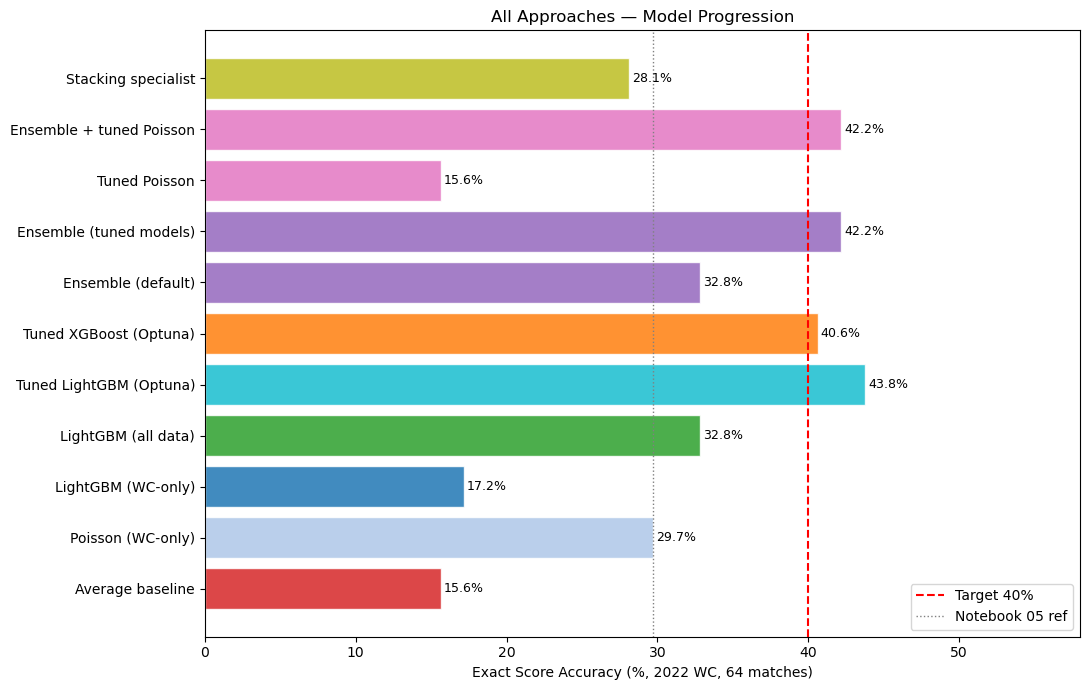


Ranked:
  Tuned LightGBM (Optuna)              43.8%  █████████████████████
  Ensemble (tuned models)              42.2%  █████████████████████
  Ensemble + tuned Poisson             42.2%  █████████████████████
  Tuned XGBoost (Optuna)               40.6%  ████████████████████
  LightGBM (all data)                  32.8%  ████████████████
  Ensemble (default)                   32.8%  ████████████████
  Poisson (WC-only)                    29.7%  ██████████████
  Stacking specialist                  28.1%  ██████████████
  LightGBM (WC-only)                   17.2%  ████████
  Average baseline                     15.6%  ███████
  Tuned Poisson                        15.6%  ███████


In [27]:

# ============================================================
# PHASE 7 SUMMARY: All approaches on 2022 World Cup
# ============================================================
print("Full progression — 2022 WC exact score accuracy")
print("="*65)

phase7 = {
    'Average baseline':        15.63,
    'Poisson (WC-only)':       pois_metrics_wc['exact_score_accuracy'],
    'LightGBM (WC-only)':      lgb_metrics_wc['exact_score_accuracy'],
    'LightGBM (all data)':     lgb_metrics_ext['exact_score_accuracy'],
    'Tuned LightGBM (Optuna)': lgb_tuned_acc,
    'Tuned XGBoost (Optuna)':  xgb_tuned_acc,
    'Ensemble (default)':      best_simple_ens_acc,
    'Ensemble (tuned models)': champion_metrics['exact_score_accuracy'],
    'Tuned Poisson':           best_pois_acc,
    'Ensemble + tuned Poisson': best_pois_ens_acc,
    # 'Neural Network':          m_nn['exact_score_accuracy'],
    'Stacking specialist':     m_stack['exact_score_accuracy'],
}

fig, ax = plt.subplots(figsize=(11, 7))
names  = list(phase7.keys())
accs   = list(phase7.values())
colors = ['#d62728', '#aec7e8', '#1f77b4', '#2ca02c', '#17becf', '#ff7f0e',
          '#9467bd', '#9467bd', '#e377c2', '#e377c2', '#bcbd22', '#8c564b']
bars = ax.barh(names, accs, color=colors[:len(names)], alpha=0.85, edgecolor='white')
ax.axvline(40, color='red',  linestyle='--', linewidth=1.5, label='Target 40%')
ax.axvline(29.69, color='gray', linestyle=':', linewidth=1, label='Notebook 05 ref')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{acc:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Exact Score Accuracy (%, 2022 WC, 64 matches)')
ax.set_title('All Approaches — Model Progression')
ax.legend(loc='lower right')
ax.set_xlim(0, 58)
plt.tight_layout()
plt.show()

print("\nRanked:")
for name, acc in sorted(phase7.items(), key=lambda x: -x[1]):
    bar = chr(9608) * int(acc / 2)
    print(f"  {name:35} {acc:5.1f}%  {bar}")
